# Data Collection
**Project:** Impact of Global Crises on Financial Markets


In [1]:
# Install libraries (run this cell only once)
!pip install yfinance fredapi pandas matplotlib

     |████████████████████████████████| 137 kB 1.2 MB/s eta 0:00:01
  Using cached requests-2.32.5-py3-none-any.whl (64 kB)
     |████████████████████████████████| 146 kB 8.6 MB/s eta 0:00:01
     |████████████████████████████████| 427 kB 15.3 MB/s eta 0:00:01
     |████████████████████████████████| 137 kB 1.4 MB/s eta 0:00:01
     |████████████████████████████████| 133 kB 8.6 MB/s eta 0:00:01
     |████████████████████████████████| 130 kB 17.3 MB/s eta 0:00:01
     |████████████████████████████████| 130 kB 38.5 MB/s eta 0:00:01
     |████████████████████████████████| 130 kB 23.2 MB/s eta 0:00:01
     |████████████████████████████████| 3.0 MB 1.9 MB/s eta 0:00:01
     |████████████████████████████████| 173 kB 16.9 MB/s eta 0:00:01
  Using cached cffi-2.0.0-cp39-cp39-macosx_11_0_arm64.whl (180 kB)
     |████████████████████████████████| 134 kB 34.9 MB/s eta 0:00:01
  Using cached pycparser-2.23-py3-none-any.whl (118 kB)
  Using cached charset_normalizer-3.4.7-cp39-cp39-macosx_10_9_unive

In [2]:
# Import libraries
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred
import os

print('All libraries imported successfully.')

/Users/yagmurcaloglu/Documents/GitHub/DSA_210_TermProject/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


All libraries imported successfully.


In [3]:

FRED_API_KEY = "2e22c2185be3bb846c2b2579a5f076f6"

# Crisis event dates
CRISES = {
    "9/11 (2001)":             "2001-09-11",
    "Iraq War (2003)":         "2003-03-20",
    "Financial Crisis (2008)": "2008-09-15",
    "COVID-19 (2020)":         "2020-03-11",
    "Russia-Ukraine (2022)":   "2022-02-24",
    "Israel-Hamas (2023)":     "2023-10-07",
}

# Financial assets to download from Yahoo Finance
TICKERS = {
    "SP500":      "^GSPC",
    "VIX":        "^VIX",
    "MSCI_World": "EFA",      
    "Defense":    "LMT",      
    "Energy":     "XLE",      
    "Health":     "XLV",      
    "Tech":       "XLK",      
    "Aviation_BA":  "BA",
    "Aviation_DAL": "DAL",     
    "Gold":       "GC=F",     
    "Oil":        "CL=F",     
}

# Macroeconomic series from FRED
FRED_SERIES = {
    "Fed_Rate": "FEDFUNDS",
    "CPI":      "CPIAUCSL",
    "Unemploy": "UNRATE",
    "M2":       "M2SL",
}

print('Settings ready.')

Settings ready.


In [4]:
# Step 1: Download financial data (yfinance)

print('Downloading financial data from Yahoo Finance...')

symbols = list(TICKERS.values())

raw = yf.download(
    tickers=symbols,
    start="2000-01-01",
    end="2025-01-01",
    progress=True
)

# Keep only closing prices
prices = raw["Close"].copy()

# Rename columns: "^GSPC" -> "SP500", "^VIX" -> "VIX", etc.
symbol_to_name = {v: k for k, v in TICKERS.items()}
prices.rename(columns=symbol_to_name, inplace=True)

# Drop rows where all values are missing (market holidays)
prices.dropna(how="all", inplace=True)

# Combine aviation: use DAL where available, BA for earlier dates
prices["Aviation"] = prices["Aviation_DAL"].fillna(prices["Aviation_BA"])
prices.drop(columns=["Aviation_DAL", "Aviation_BA"], inplace=True)

print(f'Done! {prices.shape[0]} trading days, {prices.shape[1]} assets')
print(f'Date range: {prices.index[0].date()} to {prices.index[-1].date()}')
prices.head()

[*********************100%***********************]  11 of 11 completed

Done! 6292 trading days, 10 assets
Date range: 2000-01-03 to 2024-12-31


Ticker,Oil,MSCI_World,Gold,Defense,Energy,Tech,Health,SP500,VIX,Aviation
Date,,,,,,,,,,
2000-01-03,NaN,NaN,NaN,10.412418,6.655916,20.626390,20.440752,1455.219971,24.209999,25.940277
2000-01-04,NaN,NaN,NaN,10.765927,6.530630,19.579954,19.976898,1399.420044,27.010000,25.899946
2000-01-05,NaN,NaN,NaN,10.830207,6.702903,19.289280,19.797686,1402.109985,26.410000,27.513643
2000-01-06,NaN,NaN,NaN,10.990891,6.961303,18.649792,19.860939,1403.449951,25.730000,27.796040
2000-01-07,NaN,NaN,NaN,11.023026,7.035697,18.975340,20.103407,1441.469971,21.719999,28.602909


In [5]:
# Step 2: Download macroeconomic data (FRED)
from fredapi import Fred

fred = Fred(api_key="2e22c2185be3bb846c2b2579a5f076f6")

FRED_SERIES = {
    "Fed_Rate": "FEDFUNDS",
    "CPI":      "CPIAUCSL",
    "Unemploy": "UNRATE",
    "M2":       "M2SL",
}

print("Downloading macroeconomic data from FRED...")

all_series = {}
for name, series_id in FRED_SERIES.items():
    print(f"  Downloading {name} ({series_id})...")
    series = fred.get_series(series_id, observation_start="2000-01-01", observation_end="2025-01-01")
    all_series[name] = series

macro = pd.DataFrame(all_series)
macro = macro.resample("D").ffill()
macro = macro.loc["2000-01-01":"2025-01-01"]

print(f"Done! {macro.shape[0]} days, {macro.shape[1]} indicators")
macro.head()

Done! 9133 days, 4 indicators


,Fed_Rate,CPI,Unemploy,M2
2000-01-01,5.45,169.3,4.0,4667.6
2000-01-02,5.45,169.3,4.0,4667.6
2000-01-03,5.45,169.3,4.0,4667.6
2000-01-04,5.45,169.3,4.0,4667.6
2000-01-05,5.45,169.3,4.0,4667.6


In [6]:
# Step 3: Calculate daily returns
# Return = (today's price - yesterday's price) / yesterday's price * 100
# Calculate daily returns
returns = prices.pct_change() * 100
# Drop only rows where ALL values are missing, not just some
returns.dropna(how='all', inplace=True)

print(f'Returns calculated: {returns.shape[0]} days')
returns.head()

Returns calculated: 6291 days


/var/folders/fz/h7jdtw497m121w0npqdyjrw80000gn/T/ipykernel_5787/3280402036.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change() * 100


Ticker,Oil,MSCI_World,Gold,Defense,Energy,Tech,Health,SP500,VIX,Aviation
Date,,,,,,,,,,
2000-01-04,NaN,NaN,NaN,3.395071,-1.882320,-5.073289,-2.269260,-3.834467,11.565474,-0.155476
2000-01-05,NaN,NaN,NaN,0.597065,2.637926,-1.484550,-0.897099,0.192218,-2.221401,6.230503
2000-01-06,NaN,NaN,NaN,1.483671,3.855038,-3.315252,0.319499,0.095568,-2.574783,1.026386
2000-01-07,NaN,NaN,NaN,0.292370,1.068689,1.745586,1.220828,2.709040,-15.584921,2.902822
2000-01-10,NaN,NaN,NaN,-3.790092,-0.834752,3.799109,10.225480,1.118997,-0.046042,-1.410481


In [7]:
# Step 4: Create crisis windows (30 days before and after each crisis)

windows = {}

for crisis_name, crisis_date_str in CRISES.items():
    crisis_date = pd.Timestamp(crisis_date_str)
    pre_start   = crisis_date - pd.Timedelta(days=30)
    post_end    = crisis_date + pd.Timedelta(days=30)

    windows[crisis_name] = {
        "crisis_date":  crisis_date,
        "pre_prices":   prices.loc[pre_start  : crisis_date - pd.Timedelta(days=1)],
        "post_prices":  prices.loc[crisis_date : post_end],
        "pre_returns":  returns.loc[pre_start  : crisis_date - pd.Timedelta(days=1)],
        "post_returns": returns.loc[crisis_date : post_end],
    }

    pre_len  = len(windows[crisis_name]["pre_returns"])
    post_len = len(windows[crisis_name]["post_returns"])
    print(f'{crisis_name}: {pre_len} days before, {post_len} days after')

9/11 (2001): 20 days before, 20 days after
Iraq War (2003): 22 days before, 21 days after
Financial Crisis (2008): 19 days before, 23 days after
COVID-19 (2020): 21 days before, 22 days after
Russia-Ukraine (2022): 21 days before, 22 days after
Israel-Hamas (2023): 22 days before, 21 days after


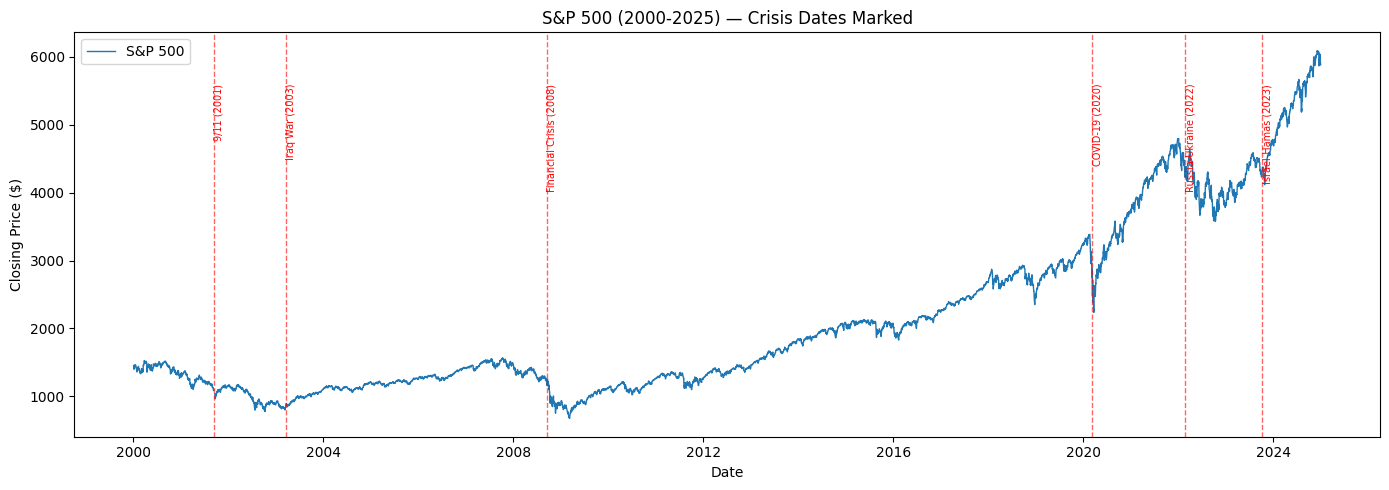

In [8]:
# Step 5: Plot S&P 500 with crisis dates marked

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(prices.index, prices["SP500"], color="#1f77b4", linewidth=1, label="S&P 500")

for crisis_name, crisis_date_str in CRISES.items():
    crisis_date = pd.Timestamp(crisis_date_str)
    ax.axvline(x=crisis_date, color="red", linestyle="--", alpha=0.6, linewidth=1)
    ax.text(crisis_date, prices["SP500"].max() * 0.92, crisis_name,
            rotation=90, fontsize=7, color="red", va="top")

ax.set_title("S&P 500 (2000-2025) — Crisis Dates Marked")
ax.set_xlabel("Date")
ax.set_ylabel("Closing Price ($)")
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# Step 6: Save all data to CSV files

# os.makedirs creates the 'data' folder automatically if it doesn't exist
save_dir = os.path.expanduser("~/Desktop/data")
os.makedirs(save_dir, exist_ok=True)

prices.to_csv(os.path.join(save_dir, "prices.csv"))
returns.to_csv(os.path.join(save_dir, "returns.csv"))
if macro is not None:
    macro.to_csv(os.path.join(save_dir, "macro.csv"))

for crisis_name, w in windows.items():
    safe_name = crisis_name.replace("/", "-").replace(" ", "_")
    w["pre_returns"].to_csv(os.path.join(save_dir, f"{safe_name}_pre.csv"))
    w["post_returns"].to_csv(os.path.join(save_dir, f"{safe_name}_post.csv"))

print("All files saved to:", save_dir)
for f in os.listdir(save_dir):
    print(f"  {f}")

All files saved to: /Users/yagmurcaloglu/Desktop/data
  Russia-Ukraine_(2022)_post.csv
  macro.csv
  COVID-19_(2020)_post.csv
  Israel-Hamas_(2023)_pre.csv
  Iraq_War_(2003)_post.csv
  COVID-19_(2020)_pre.csv
  prices.csv
  Financial_Crisis_(2008)_post.csv
  Russia-Ukraine_(2022)_pre.csv
  Israel-Hamas_(2023)_post.csv
  9-11_(2001)_pre.csv
  9-11_(2001)_post.csv
  Financial_Crisis_(2008)_pre.csv
  returns.csv
  Iraq_War_(2003)_pre.csv


## Summary

| Variable | What it contains |
|---|---|
| `prices` | Daily closing prices for all assets (2000–2025) |
| `returns` | Daily percentage change for all assets |
| `macro` | Interest rate, CPI, unemployment, money supply |
| `windows` | 30-day pre and post data for each crisis |


In [10]:
print("Dataset overview:")
print(f"  - {prices.shape[0]} trading days, {prices.shape[1]} assets")
print(f"  - Date range: 2000-01-03 to 2024-12-31")
print(f"  - Aviation: combined BA (pre-2007) + DAL (post-2007)")
print(f"  - Macro indicators: Fed Rate, CPI, Unemployment, M2")
print(f"  - Crisis windows: {len(CRISES)} events × pre/post 30 days")

Dataset overview:
  - 6292 trading days, 10 assets
  - Date range: 2000-01-03 to 2024-12-31
  - Aviation: combined BA (pre-2007) + DAL (post-2007)
  - Macro indicators: Fed Rate, CPI, Unemployment, M2
  - Crisis windows: 6 events × pre/post 30 days
